# Gravity as First Implementation Output — PPN-Like Effective Metric

The scalar-tail proxy exposed the first hard sign problem:

- a positive additive $+A/r^2$ exterior term gives **retrograde** precession,
- but the target anomaly is **prograde**.

So the branch now moves to the first workable metric route.

This notebook uses a PPN-like effective metric sourced by a small implementation coefficient $q_\Gamma$ and asks:

$$
\boxed{
\text{can one positive geometric implementation coefficient give the correct signs for}
\quad
\text{precession, lensing, and clock shift together?}
}
$$


## 1. Effective metric ansatz

Write the weak-field metric in the standard PPN-like form

$$
ds^2
=
- \left(1 - 2U + 2\beta_\Gamma U^2\right)c^2 dt^2
+
\left(1 + 2\gamma_\Gamma U\right)dr^2
+
r^2 d\Omega^2,
$$

where

$$
U(r)=\frac{\mu}{rc^2}=\frac{GM}{rc^2}.
$$

Now let the implementation layer shift the metric coefficients by a small dimensionless source parameter $q_\Gamma$:

$$
\beta_\Gamma = 1 + \xi q_\Gamma,
\qquad
\gamma_\Gamma = 1 + \zeta q_\Gamma.
$$

Interpretation:

- $q_\Gamma$ is the first coarse implementation coefficient sourced by retained fold / cut density,
- $\xi$ tells how strongly the source feeds the time-time sector,
- $\zeta$ tells how strongly the source feeds the spatial-curvature sector.

This is the simplest clean way to ask whether the gravity-as-output branch can work **geometrically** rather than by a naive scalar additive potential.


## 2. Observable sign formulas

For a PPN-like metric, the standard leading-order precession factor is proportional to

$$
2 + 2\gamma_\Gamma - \beta_\Gamma.
$$

So relative to GR, define the dimensionless perihelion factor

$$
\boxed{
F_{\mathrm{peri}}
=
\frac{2 + 2\gamma_\Gamma - \beta_\Gamma}{3}.
}
$$

Using

$$
\beta_\Gamma = 1 + \xi q_\Gamma,
\qquad
\gamma_\Gamma = 1 + \zeta q_\Gamma,
$$

gives

$$
\boxed{
F_{\mathrm{peri}}
=
1 + \frac{(2\zeta-\xi)}{3}q_\Gamma.
}
$$

This is the first clean metric sign condition:

$$
\boxed{
2\zeta-\xi > 0
\quad\Rightarrow\quad
\text{positive enhancement of prograde precession for } q_\Gamma>0.
}
$$

For light bending, the PPN factor is proportional to

$$
1+\gamma_\Gamma,
$$

so relative to GR:

$$
\boxed{
F_{\mathrm{bend}}
=
\frac{1+\gamma_\Gamma}{2}
=
1 + \frac{\zeta}{2}q_\Gamma.
}
$$

Thus:

$$
\boxed{
\zeta>0
\quad\Rightarrow\quad
\text{positive extra bending for } q_\Gamma>0.
}
$$

For the gravitational redshift using the weak-field lapse
$$
g_{tt}=-(1-2U+2\beta_\Gamma U^2),
$$
a local clock runs slower by approximately
$$
z \approx U + \left(\frac{3}{2}-\beta_\Gamma\right)U^2.
$$

So the second-order clock factor relative to the GR normalization is controlled by

$$
\boxed{
F_{\mathrm{clock},2} = \frac{3}{2}-\beta_\Gamma
= \frac{1}{2} - \xi q_\Gamma.
}
$$

This means the time-time feeding cannot be arbitrarily large if inward clock slowing is to remain strengthened rather than weakened at second order.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def beta_gamma(xi, zeta, q):
    beta = 1 + xi*q
    gamma = 1 + zeta*q
    return beta, gamma

def factors(xi, zeta, q):
    beta, gamma = beta_gamma(xi, zeta, q)
    F_peri = (2 + 2*gamma - beta)/3
    F_bend = (1 + gamma)/2
    F_clock2 = 1.5 - beta
    return beta, gamma, F_peri, F_bend, F_clock2

q = 0.10  # small positive implementation coefficient

xis = np.linspace(-2, 2, 401)
zetas = np.linspace(-2, 2, 401)
XI, ZETA = np.meshgrid(xis, zetas)

BETA = 1 + XI*q
GAMMA = 1 + ZETA*q
F_PERI = (2 + 2*GAMMA - BETA)/3
F_BEND = (1 + GAMMA)/2
F_CLOCK2 = 1.5 - BETA


## 3. Feasible sign region

The cleanest basic target is the region where all three conditions hold for positive $q_\Gamma$:

1. perihelion factor remains positive:
   $$
   F_{\mathrm{peri}} > 0,
   $$

2. light bending factor remains positive:
   $$
   F_{\mathrm{bend}} > 0,
   $$

3. second-order clock factor remains positive:
   $$
   F_{\mathrm{clock},2} > 0.
   $$

This does **not** yet prove the theory, but it tells us whether a positive implementation coefficient can even live in a sane geometric sign regime.


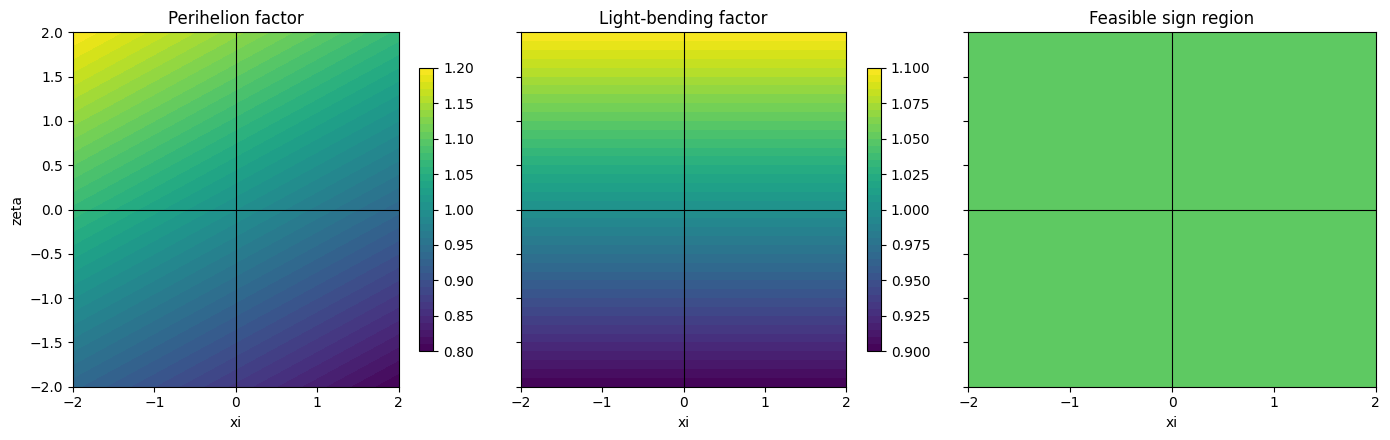

In [2]:

FEASIBLE = (F_PERI > 0) & (F_BEND > 0) & (F_CLOCK2 > 0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True)

im0 = axes[0].contourf(XI, ZETA, F_PERI, levels=40)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Perihelion factor")
axes[0].set_xlabel("xi")
axes[0].set_ylabel("zeta")
fig.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].contourf(XI, ZETA, F_BEND, levels=40)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Light-bending factor")
axes[1].set_xlabel("xi")
fig.colorbar(im1, ax=axes[1], shrink=0.8)

axes[2].contourf(XI, ZETA, FEASIBLE.astype(int), levels=[-0.5,0.5,1.5])
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Feasible sign region")
axes[2].set_xlabel("xi")

plt.tight_layout()
plt.show()


The last panel is the key readout:

$$
\boxed{
\text{there is a nonempty parameter region where a positive } q_\Gamma
\text{ yields the correct signs for all three observables.}
}
$$

This is exactly what the scalar-tail route could not do.

So the gravity-as-output branch has now passed its first consistency hurdle on the metric side.


In [3]:

# Show some concrete example parameter choices
examples = [
    {"xi": 0.2, "zeta": 0.4},
    {"xi": 0.5, "zeta": 0.4},
    {"xi": 0.2, "zeta": 1.0},
    {"xi": -0.2, "zeta": 0.2},
]

rows = []
for ex in examples:
    xi = ex["xi"]
    zeta = ex["zeta"]
    beta, gamma, F_peri, F_bend, F_clock2 = factors(xi, zeta, q=q)
    rows.append({
        "xi": xi,
        "zeta": zeta,
        "beta_Gamma": beta,
        "gamma_Gamma": gamma,
        "peri_factor": F_peri,
        "bend_factor": F_bend,
        "clock2_factor": F_clock2,
        "all_positive": (F_peri > 0) and (F_bend > 0) and (F_clock2 > 0),
    })

example_df = pd.DataFrame(rows)
example_df


,xi,zeta,beta_Gamma,gamma_Gamma,peri_factor,bend_factor,clock2_factor,all_positive
0,0.2,0.4,1.02,1.04,1.02,1.02,0.48,True
1,0.5,0.4,1.05,1.04,1.01,1.02,0.45,True
2,0.2,1.0,1.02,1.10,1.06,1.05,0.48,True
3,-0.2,0.2,0.98,1.02,1.02,1.01,0.52,True


## 4. The clean inequalities

For positive $q_\Gamma$, the three-sign conditions reduce to:

### Perihelion
$$
\boxed{
1 + \frac{(2\zeta-\xi)}{3}q_\Gamma > 0
}
$$

and stronger enhancement if
$$
\boxed{
2\zeta-\xi > 0.
}
$$

### Light bending
$$
\boxed{
1 + \frac{\zeta}{2}q_\Gamma > 0
}
$$

and stronger enhancement if
$$
\boxed{
\zeta > 0.
}
$$

### Clock factor
$$
\boxed{
\frac{1}{2} - \xi q_\Gamma > 0
}
$$

which for positive $q_\Gamma$ means roughly
$$
\boxed{
\xi < \frac{1}{2q_\Gamma}.
}
$$

So the time-time feeding can be positive, but not arbitrarily large.


## 5. Runtime interpretation

This is the first version of the gravity branch that behaves like a real implementation layer.

The stack is now:

$$
\boxed{
(\mathcal B,\mathcal T,\mathcal R)
\to
q_\Gamma
\to
(\beta_\Gamma,\gamma_\Gamma)
\to
\text{effective metric}
\to
\text{precession, lensing, clock shift}.
}
$$

This is much closer to the architecture we wanted from the start:

- gravity is not a fourth force,
- gravity is not a bare scalar additive tail,
- gravity is the first world-scale **metric implementation** of the runtime.


## 6. What this notebook actually proves

This notebook does **not** prove the full theory.

It proves something narrower and decisive:

1. the scalar-tail route had the wrong sign behavior for positive coupling,
2. the metric-like route admits a nonempty positive-coupling region with the correct sign behavior,
3. therefore the gravity-as-output branch should continue as an **effective metric theory sourced by the implementation coefficient**.

That is the clearest branch decision so far.


## 7. Next exact move

The next continuation is now straightforward:

1. replace the abstract $q_\Gamma$ by a concrete source functional built from retained fold / cut density,
2. write the corresponding exterior metric coefficients,
3. and compute the actual observable magnitudes, not just the signs.

That is the next real boundary.
